<a href="https://colab.research.google.com/github/franroca15/pdi-peptide-ml-prediction/blob/main/esm_protein_peptides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

# Define your GitHub raw URL
# Make sure your repository is public and the branch is 'main'
repo_url = "https://raw.githubusercontent.com/franroca15/pdi-peptide-ml-prediction/main"

files_to_download = [
    "protein_peptide_contacts.csv",
    "Pdi_peptides.csv",
    "predict_2.py"
]

print("[INFO] Downloading required files from GitHub...")
for file in files_to_download:
    if not os.path.exists(file):
        !wget -q {repo_url}/{file} -O {file}
        print(f"Downloaded: {file}")
    else:
        print(f"Already exists: {file}")
print("[OK] All files ready.")

[INFO] Downloading required files from GitHub...
Downloaded: protein_peptide_contacts.csv
Downloaded: Pdi_peptides.csv
Downloaded: predict_2.py
[OK] All files ready.


In [3]:
!pip install fair-esm torch scikit-learn pandas numpy matplotlib seaborn --quiet
# Install the source for contextual embeddings (ESM)
# and the deep learning framework on which ESM models are built and executed.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np

# Database loading, initialization, and cleaning
csv_path = "protein_peptide_contacts.csv"
df = pd.read_csv(csv_path)

pep_col = "pep_sequence"
prot_col = "prot_sequence"
contacts_col = "n_contacts_txt"

df = df.dropna(subset=[pep_col, prot_col, contacts_col]).copy() # Drop rows with missing critical information
df[pep_col] = df[pep_col].astype(str).str.strip() # Convert sequence columns to string and strip whitespace
df[prot_col] = df[prot_col].astype(str).str.strip()
df[contacts_col] = pd.to_numeric(df[contacts_col], errors="coerce") # Convert contacts column to numeric
df = df.dropna(subset=[contacts_col]) # Drop rows that resulted in NaN
df = df[(df[pep_col].str.len() > 0) & (df[prot_col].str.len() > 0)] # Filter out rows with empty sequences

# Sanity check: print total rows, unique peptides, and unique proteins
print(f"Total rows: {len(df)}, Unique peptides: {df[pep_col].nunique()}, Unique proteins: {df[prot_col].nunique()}")

Total rows: 13154, Unique peptides: 7747, Unique proteins: 8074


In [5]:
import torch
import esm

# Prepare the ESM model to receive protein sequences and convert them into embeddings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "esm2_t6_8M_UR50D"  # Small model

# Download and load components: neural network and amino acid vocabulary
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
model = model.to(device) # Move the model to GPU memory
model.eval() # Set model to evaluation mode

# Initialize an ESM tool that converts strings to tokens for batch processing
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [6]:
# Core function to generate embeddings.
# Translates evolutionary information captured by ESM into feature vectors
def embed_sequences_esm(model, alphabet, seqs, batch_size=64, device="cpu"):
    batch_converter = alphabet.get_batch_converter() # Get the tool to transform text sequences into numerical tensors
    model = model.to(device)
    all_vecs = [] # Empty list to store final embeddings

    with torch.no_grad(): # Disable gradient calculation and storage
        for i in range(0, len(seqs), batch_size): # Iterate over sequences
            torch.cuda.empty_cache() # Clear CUDA cache before each batch
            batch_seqs = seqs[i:i+batch_size] # Select current batch of sequences to process
            data = [(str(j), s) for j, s in enumerate(batch_seqs)]
            labels, strs, tokens = batch_converter(data) # Tokenization
            tokens = tokens.to(device)
            out = model(tokens, repr_layers=[model.num_layers]) # Pass tokens through the ESM model
            reps = out["representations"][model.num_layers] # Get the representation matrix from the final layer

            for rep, seq in zip(reps, strs):
                L = len(seq)
                vec = rep[1:L+1].mean(0) # Define the embedding
                all_vecs.append(vec.cpu().numpy()) # Combine all final embeddings into a single NumPy array

    return np.vstack(all_vecs)

In [7]:
# Execution step to generate the actual embeddings
pep_seqs = sorted(df[pep_col].astype(str).unique()) # Extract all remaining unique peptide sequences
prot_seqs = sorted(df[prot_col].astype(str).unique()) # Same for proteins

# Call the previous function, pass the model, sequences, and hardware settings
pep_vecs = embed_sequences_esm(model, alphabet, pep_seqs, batch_size=4, device=device)
prot_vecs = embed_sequences_esm(model, alphabet, prot_seqs, batch_size=4, device=device)

print(f"Peptide vectors shape: {pep_vecs.shape}, Protein vectors shape: {prot_vecs.shape}")

# Save embeddings for reuse
np.savez("pep_esm_embeds.npz", seqs=np.array(pep_seqs, dtype=object), vecs=pep_vecs)
np.savez("prot_esm_embeds.npz", seqs=np.array(prot_seqs, dtype=object), vecs=prot_vecs)

Peptide vectors shape: (7747, 320), Protein vectors shape: (8074, 320)


In [8]:
# --- P50 (MEDIAN) THRESHOLD LOGIC ---
def info(msg: str):
    print(f"[INFO] {msg}")

umbral_p50 = df[contacts_col].median()

info(f"Calculated dynamic threshold (P50): {umbral_p50}")
info(f"Strong (1) >= {umbral_p50} | Weak (0) < {umbral_p50}")

# Assign label 'y' based on the median
df["y"] = (df[contacts_col] >= umbral_p50).astype(int)

# Link with Embeddings (X and y)
pep_dict = {s: v for s, v in zip(pep_seqs, pep_vecs)}
prot_dict = {s: v for s, v in zip(prot_seqs, prot_vecs)}

X_list = []
y_list = []
valid_indices = []

for idx, row in df.iterrows():
    sp = row[pep_col]
    st = row[prot_col]
    if sp in pep_dict and st in prot_dict:
        X_list.append(np.concatenate([pep_dict[sp], prot_dict[st]]))
        y_list.append(row["y"])
        valid_indices.append(idx)

X = np.vstack(X_list)
y = np.array(y_list)

# Synchronize the original DataFrame with the generated vectors
data = df.loc[valid_indices].reset_index(drop=True)

print(f"\nFinal summary:")
print(f"X shape: {X.shape}")
print(f"Strong Class (1): {(y==1).sum()}")
print(f"Weak Class (0): {(y==0).sum()}")

[INFO] Calculated dynamic threshold (P50): 62.0
[INFO] Strong (1) >= 62.0 | Weak (0) < 62.0

Final summary:
X shape: (13154, 640)
Strong Class (1): 6766
Weak Class (0): 6388


Train: 7871 | Val: 2629 | Test: 2654
VAL AUC = 0.9305311568886074
TEST AUC = 0.9208908772059471
VAL AP  = 0.9311444399609196
TEST AP = 0.9183413340573394
[INFO] Classifier model saved: ppi_esm_logreg_final_model.pkl


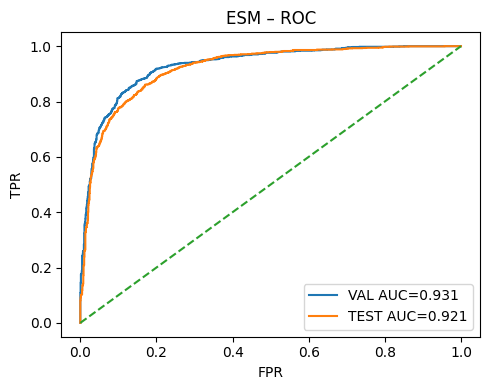

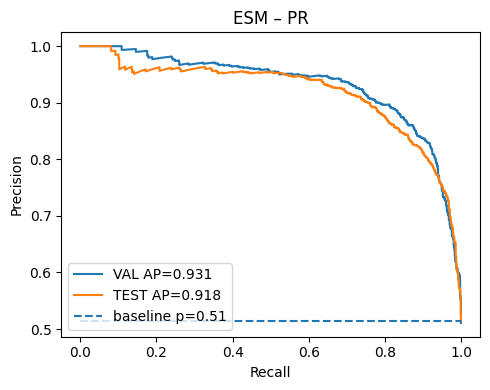

In [9]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import joblib

# Group by pdb_id (if the column exists)
group_col = "pdb_id" if "pdb_id" in data.columns else prot_col
groups = data.loc[data.index[:len(y)], group_col].astype(str).values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_all = np.arange(len(y))
trval_idx, test_idx = next(gss1.split(idx_all.reshape(-1,1), y, groups))

val_prop = 0.2 / 0.8
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_prop, random_state=42)
tr_idx, val_idx = next(gss2.split(trval_idx.reshape(-1,1), y[trval_idx], groups[trval_idx]))

train_idx, val_idx = trval_idx[tr_idx], trval_idx[val_idx]
X_tr, X_va, X_te = X[train_idx], X[val_idx], X[test_idx]
y_tr, y_va, y_te = y[train_idx], y[val_idx], y[test_idx]

print(f"Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

clf = LogisticRegression(max_iter=2000, solver="lbfgs")
clf.fit(X_tr, y_tr)

s_va = clf.predict_proba(X_va)[:,1]
s_te = clf.predict_proba(X_te)[:,1]

print("VAL AUC =", roc_auc_score(y_va, s_va))
print("TEST AUC =", roc_auc_score(y_te, s_te))
print("VAL AP  =", average_precision_score(y_va, s_va))
print("TEST AP =", average_precision_score(y_te, s_te))

model_path = "ppi_esm_logreg_final_model.pkl"
joblib.dump(clf, model_path)
print(f"[INFO] Classifier model saved: {model_path}")

# ROC Curve Plot
plt.figure(figsize=(5,4))
fpr_v, tpr_v, _ = roc_curve(y_va, s_va)
fpr_t, tpr_t, _ = roc_curve(y_te, s_te)
auc_v = roc_auc_score(y_va, s_va)
auc_t = roc_auc_score(y_te, s_te)
plt.plot(fpr_v, tpr_v, label=f"VAL AUC={auc_v:.3f}")
plt.plot(fpr_t, tpr_t, label=f"TEST AUC={auc_t:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ESM – ROC")
plt.legend(); plt.tight_layout()
plt.show()

# Precision-Recall Curve Plot
plt.figure(figsize=(5,4))
prec_v, rec_v, _ = precision_recall_curve(y_va, s_va)
prec_t, rec_t, _ = precision_recall_curve(y_te, s_te)
ap_v = average_precision_score(y_va, s_va)
ap_t = average_precision_score(y_te, s_te)
plt.plot(rec_v, prec_v, label=f"VAL AP={ap_v:.3f}")
plt.plot(rec_t, prec_t, label=f"TEST AP={ap_t:.3f}")
base = y.mean()
plt.hlines(base, 0, 1, linestyles="dashed", label=f"baseline p={base:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("ESM – PR")
plt.legend(); plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
from google.colab import files

print("[INFO] Generating validation results for the Embedding model...")

# 1. Get probabilities using the 'clf' classifier on X_va (validation set)
val_probs = s_va

# 2. Get the original sequences corresponding to the validation indices
df_val_results = pd.DataFrame({
    'pep_sequence': data.iloc[val_idx][pep_col].values,
    'interaction_probability': val_probs
})

# 3. Save the CSV file
output_val_name = "val_results_embedding.csv"
df_val_results.to_csv(output_val_name, index=False)

# 4. Download automatically
files.download(output_val_name)
print(f"[OK] File '{output_val_name}' generated and ready for download.")

[INFO] Generating validation results for the Embedding model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] File 'val_results_embedding.csv' generated and ready for download.


In [11]:
# Run external prediction script
!python predict_2.py \
  --clf-path ppi_esm_logreg_final_model.pkl \
  --new-data Pdi_peptides.csv \
  --model-name esm2_t6_8M_UR50D \
  --device cuda \
  --batch-size 16 \
  --out ppi_prediction_final_esm_new.csv

# Load results to verify
df_results = pd.read_csv("ppi_prediction_final_esm_new.csv")
clf = joblib.load("ppi_esm_logreg_final_model.pkl")
print(f"Data loaded: {df_results.shape[0]} peptides.")

[INFO] Adding possible contacts column...
[INFO] Process finished. Results saved in: ppi_prediction_final_esm_new.csv
Data loaded: 34 peptides.


✅ Model loaded from ppi_esm_logreg_final_model.pkl
✅ Data loaded: 34 peptides found.
🧬 Generating ESM-2 representations in real time...


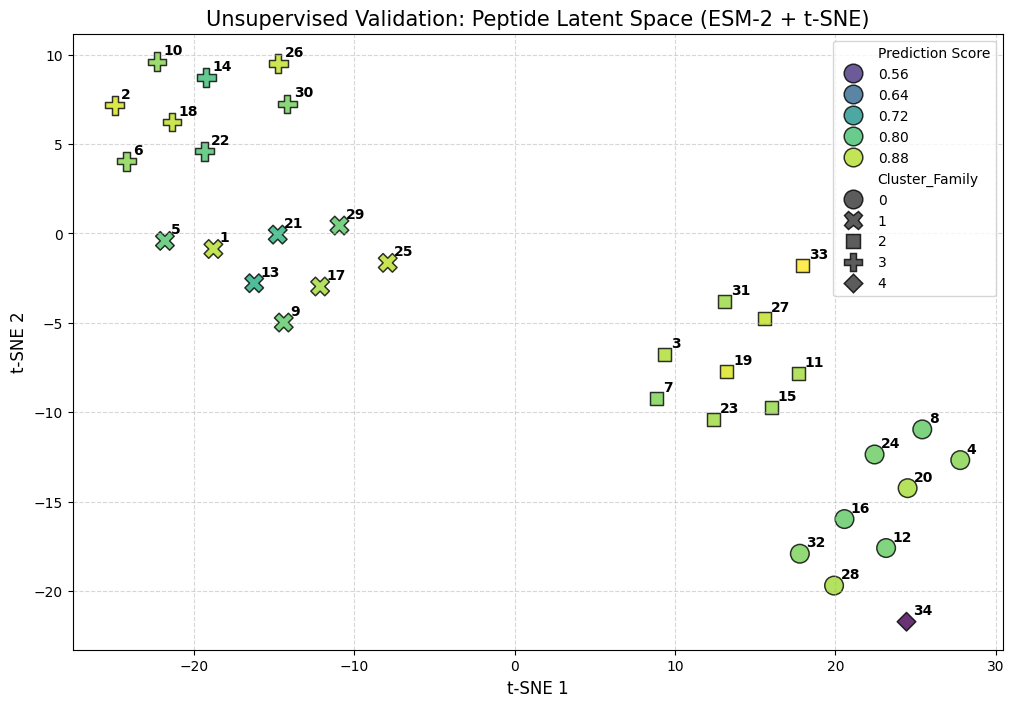

✅ Analysis completed. This plot validates if your top-scoring peptides share structural families.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ==========================================
# 1. LOAD MODEL AND DATA
# ==========================================
model_path = "ppi_esm_logreg_final_model.pkl"
csv_path = "ppi_prediction_final_esm_new.csv"

try:
    # Load the trained classifier
    clf_final = joblib.load(model_path)
    # Load the results ranking
    df_ranking = pd.read_csv(csv_path)

    print(f"✅ Model loaded from {model_path}")
    print(f"✅ Data loaded: {len(df_ranking)} peptides found.")

    # ==========================================
    # 2. LOCAL DEFINITION OF EXTRACT_VECTORS
    # ==========================================
    # We use 'model', 'alphabet', and 'device' as defined in the previous cells
    def extract_vectors(sequences):
        embeddings_dict = {}
        model.eval()
        converter = alphabet.get_batch_converter()

        for seq in set(sequences):
            data = [("label", seq)]
            _, _, tokens = converter(data)
            tokens = tokens.to(device)
            with torch.no_grad():
                results = model(tokens, repr_layers=[6])
                # Final layer representation (mean pooling)
                seq_rep = results["representations"][6][0, 1 : len(seq) + 1].mean(0)
                embeddings_dict[seq] = seq_rep.cpu().numpy()
        return embeddings_dict

    # ==========================================
    # 3. STRUCTURAL PROCESSING
    # ==========================================
    print("🧬 Generating ESM-2 representations in real time...")
    # Use the 'pep_sequence' column
    pep_dict_local = extract_vectors(df_ranking['pep_sequence'].tolist())
    X_embeddings = np.array([pep_dict_local[s] for s in df_ranking['pep_sequence']])

    # K-Means Clustering (grouping into 5 structural families)
    df_ranking['Cluster_Family'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_embeddings)

    # t-SNE dimensionality reduction for visualization
    tsne_engine = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne_engine.fit_transform(X_embeddings)
    df_ranking['tsne_1'] = X_tsne[:, 0]
    df_ranking['tsne_2'] = X_tsne[:, 1]

    df_ranking = df_ranking.rename(columns={
        'prediction_score': 'Prediction Score'
    })

    # ==========================================
    # 4. SCIENTIFIC VISUALIZATION
    # ==========================================
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_ranking, x='tsne_1', y='tsne_2',
        hue='Prediction Score', style='Cluster_Family',
        palette='viridis', s=180, edgecolor='black', alpha=0.8
    )

    # Peptide numbering for thesis report
    for i in range(len(df_ranking)):
        plt.text(df_ranking.tsne_1.iloc[i]+0.4, df_ranking.tsne_2.iloc[i]+0.4, str(i+1), fontsize=10, weight='bold')

    plt.title('Unsupervised Validation: Peptide Latent Space (ESM-2 + t-SNE)', fontsize=15)
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Save the plot before showing it
    output_tsne_img = "pdi_latent_space_tsne.png"
    plt.savefig(output_tsne_img, dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Analysis completed. This plot validates if your top-scoring peptides share structural families.")

except Exception as e:
    print(f"❌ Critical error: {e}")
    print("Note: Ensure your runtime has an active GPU.")